# AdaLux — Domande di ricerca (Q1/Q2/Q3)

Carica i modelli PPO/SAC già allenati da `01_training.ipynb` (in
`models/`) e risponde alle tre domande di ricerca:

- **Q1** — Un agente RL supera un controllore a soglie fisse?
- **Q2** — Quale algoritmo converge meglio ed evita ottimi locali?
- **Q3** — La policy resta affidabile fuori distribuzione?

Se non hai ancora allenato i modelli, esegui prima `01_training.ipynb`.

## 0. Setup

In [3]:
import os
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

%matplotlib inline

from stable_baselines3 import PPO, SAC

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "modules")))
from lighting_env import AdaLux
from baseline_controller import ThresholdController
from eval_utils import (
    colors_algo,
    energy_cost_eur,
    episode_metrics,
    evaluate_over_seeds,
    plot_day,
    run_episode,
    smoothed_reward_curve,
)

MODELS_DIR = "../models"
LOGS_DIR = "../logs"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 110


In [4]:
# Deve combaciare con i valori usati in 01_training.ipynb per allenare i modelli
FAST_MODE = False
N_SEEDS = 3
TIMESTEPS = 20_000 if FAST_MODE else 80_000
N_TEST_EPISODES = 10 if FAST_MODE else 30

print(f"FAST_MODE={FAST_MODE} | N_SEEDS={N_SEEDS} | TIMESTEPS={TIMESTEPS} - "
      f"N_TEST_EPISODES={N_TEST_EPISODES}")


FAST_MODE=False | N_SEEDS=3 | TIMESTEPS=80000 - N_TEST_EPISODES=30


In [5]:
DEVICE = "cpu"  # dispositivo usato per caricare/eseguire i modelli qui

cuda_available = torch.cuda.is_available()
print(f"DEVICE = {DEVICE!r}")


DEVICE = 'cpu'


## 1. Caricamento modelli allenati e valutazione sui test seed

In [6]:
SEEDS = list(range(1, N_SEEDS + 1))
ALGO_CLASSES = {"PPO": PPO, "SAC": SAC}

models = {}
logs = {}
for seed in SEEDS:
    for algo_name, algo_cls in ALGO_CLASSES.items():
        save_path = os.path.join(MODELS_DIR, f"{algo_name.lower()}_q2_seed{seed}")
        if not os.path.exists(save_path + ".zip"):
            raise FileNotFoundError(
                f"{save_path}.zip non trovato — esegui prima 01_training.ipynb "
                f"con N_SEEDS >= {seed}."
            )
        models[(algo_name, seed)] = algo_cls.load(save_path, device=DEVICE)
        logs[(algo_name, seed)] = os.path.join(LOGS_DIR, f"q2_{algo_name.lower()}_seed{seed}")

print(f"{len(models)} modelli caricati da disco ({len(SEEDS)} seed x 2 algoritmi).")


6 modelli caricati da disco (3 seed x 2 algoritmi).


In [7]:
# Seed dei set di test, NON sovrapposti ai seed usati in training
TEST_SEEDS = list(range(1000, 1000 + N_TEST_EPISODES))
print(f"{len(TEST_SEEDS)} seed di test: {TEST_SEEDS[:5]}...")

QUAL_SEED = TEST_SEEDS[0]  # stesso episodio di test riusato per le osservazioni qualitative in Q1/Q2/Q3


30 seed di test: [1000, 1001, 1002, 1003, 1004]...


In [8]:
rows = []
for (algo_name, seed), model in tqdm(list(models.items()), desc="Valutazione su TEST_SEEDS"):
    df_ep = evaluate_over_seeds(model, TEST_SEEDS, label=algo_name)
    df_ep["train_seed"] = seed
    rows.append(df_ep)

df_eval = pd.concat(rows, ignore_index=True)  # una riga per (algoritmo, training seed, episodio di test)
df_eval["energy_cost_eur"] = df_eval["energy_kwh"].apply(energy_cost_eur)

# Tabella riassuntiva mostrata PER CIASCUN training seed
summary_per_seed = df_eval.groupby(["policy", "train_seed"])[
    ["mean_lux_error_pct", "energy_kwh", "energy_cost_eur", "mean_blind_pos_occ", "jitter_mean"]
].mean()
summary_per_seed


Valutazione su TEST_SEEDS:   0%|          | 0/6 [00:00<?, ?it/s]

Valutazione PPO:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione SAC:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione PPO:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione SAC:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione PPO:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione SAC:   0%|          | 0/30 [00:00<?, ?it/s]

mean_lux_error_pct  energy_kwh  energy_cost_eur  \
policy train_seed                                                    
PPO    1                    32.014574    0.124171         0.031043   
       2                    32.676946    0.150812         0.037703   
       3                    31.783610    0.146167         0.036542   
SAC    1                     4.710461    0.028737         0.007184   
       2                     5.111760    0.024771         0.006193   
       3                     5.643596    0.027501         0.006875   

                   mean_blind_pos_occ  jitter_mean  
policy train_seed                                   
PPO    1                     0.020377     0.171162  
       2                     0.058581     0.181361  
       3                     0.006270     0.169142  
SAC    1                     0.321401     0.034355  
       2                     0.331653     0.031758  
       3                     0.314029     0.033923

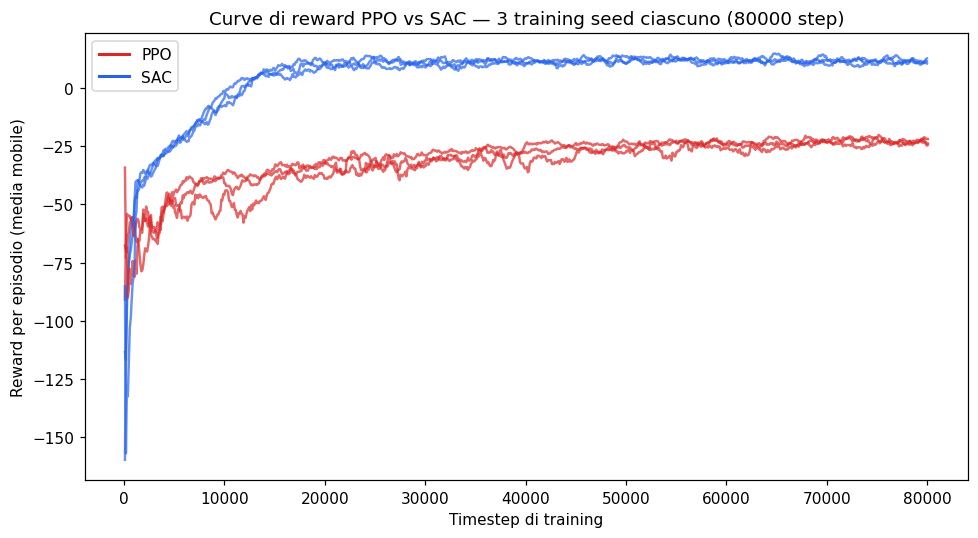

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for (algo_name, seed), log_dir in logs.items():
    x, y = smoothed_reward_curve(log_dir)
    ax.plot(x, y, color=colors_algo[algo_name], alpha=0.7, linewidth=1.6)

ax.legend(handles=[Line2D([0], [0], color=c, lw=2, label=a) for a, c in colors_algo.items()])
ax.set_xlabel("Timestep di training")
ax.set_ylabel("Reward per episodio (media mobile)")
ax.set_title(f"Curve di reward PPO vs SAC — {len(SEEDS)} training seed ciascuno ({TIMESTEPS} step)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "reward_curves.png"), dpi=150)
plt.show()


## 2. Q1 — Un agente RL supera un controllore a soglie fisse?

Il Baseline `ThresholdController` ha queste caratteristiche:

- tarato su un **setpoint nominale fisso** (500 lux) e **non conosce** il
  target reale richiesto nell'episodio;
- tapparella su pochi livelli discreti scelti da soglie di lux assolute;
- LED con controllo ON-OFF e banda morta attorno al setpoint nominale.

In [10]:
baseline = ThresholdController()
df_baseline = evaluate_over_seeds(baseline, TEST_SEEDS, is_baseline=True, label="Baseline (soglie fisse)")

sac_for_q1 = models[("SAC", SEEDS[0])]
df_sac_q1 = df_eval[(df_eval.policy == "SAC") & (df_eval.train_seed == SEEDS[0])].drop(columns=["train_seed"])

df_q1 = pd.concat([df_baseline, df_sac_q1], ignore_index=True)
df_q1["energy_cost_eur"] = df_q1["energy_kwh"].apply(energy_cost_eur)
summary_q1 = df_q1.groupby("policy")[["mean_lux_error_pct", "energy_kwh", "energy_cost_eur"]].agg(["mean", "std"])
summary_q1


Valutazione Baseline (soglie fisse):   0%|          | 0/30 [00:00<?, ?it/s]

mean_lux_error_pct            energy_kwh            \
                                      mean        std       mean       std   
policy                                                                       
Baseline (soglie fisse)         109.242555  55.083683   0.020020  0.012390   
SAC                               4.710461   2.087533   0.028737  0.013311   

                        energy_cost_eur            
                                   mean       std  
policy                                             
Baseline (soglie fisse)        0.005005  0.003097  
SAC                            0.007184  0.003328

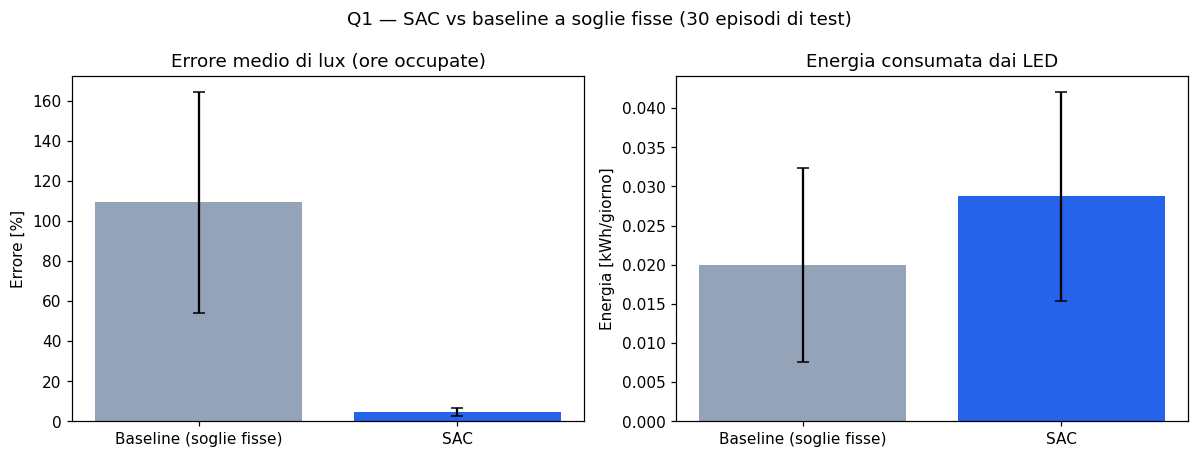

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, col, title, ylabel in [
    (axes[0], "mean_lux_error_pct", "Errore medio di lux (ore occupate)", "Errore [%]"),
    (axes[1], "energy_kwh", "Energia consumata dai LED", "Energia [kWh/giorno]"),
]:
    means = df_q1.groupby("policy")[col].mean()
    stds = df_q1.groupby("policy")[col].std()
    ax.bar(means.index, means.values, yerr=stds.values, capsize=4,
           color=["#94a3b8", "#2563eb"])
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f"Q1 — SAC vs baseline a soglie fisse ({len(TEST_SEEDS)} episodi di test)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q1_sac_vs_baseline.png"), dpi=150)
plt.show()


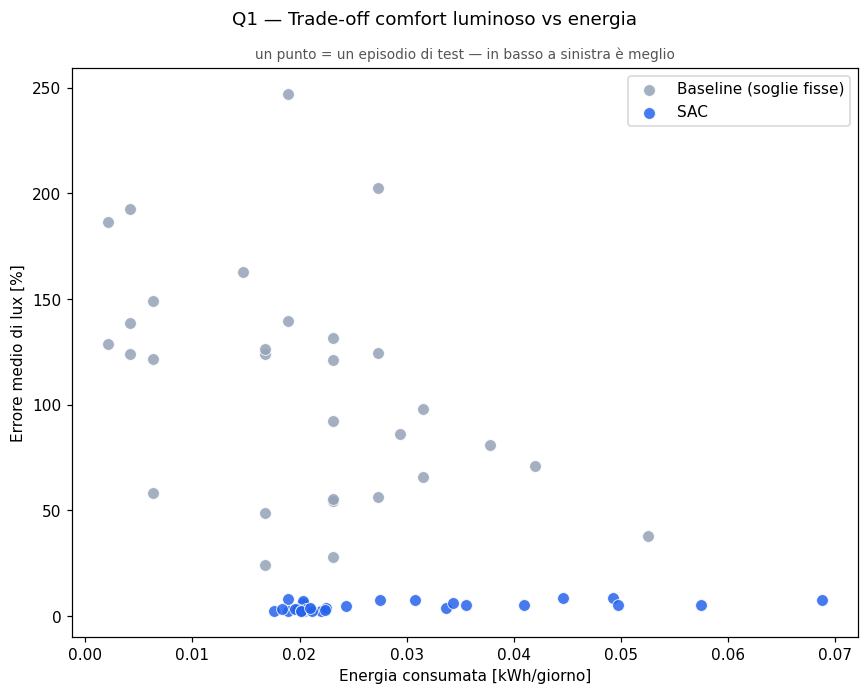

In [12]:
fig, ax = plt.subplots(figsize=(8, 6.4))

colors = {"Baseline (soglie fisse)": "#94a3b8", "SAC": "#2563eb"}
for policy, color in colors.items():
    sub = df_q1[df_q1.policy == policy]
    ax.scatter(sub["energy_kwh"], sub["mean_lux_error_pct"], label=policy,
               color=color, s=60, alpha=0.85, edgecolor="white", linewidth=0.6)

ax.set_xlabel("Energia consumata [kWh/giorno]")
ax.set_ylabel("Errore medio di lux [%]")
fig.suptitle("Q1 — Trade-off comfort luminoso vs energia", fontsize=12, y=0.98)
ax.set_title("un punto = un episodio di test — in basso a sinistra è meglio",
             fontsize=9, color="#555555")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q1_tradeoff_scatter.png"), dpi=150)
plt.show()


### Osservazione qualitativa

Stesso episodio di test  per baseline e SAC, per vedere concretamente come
si comportano i due controllori ora per ora.

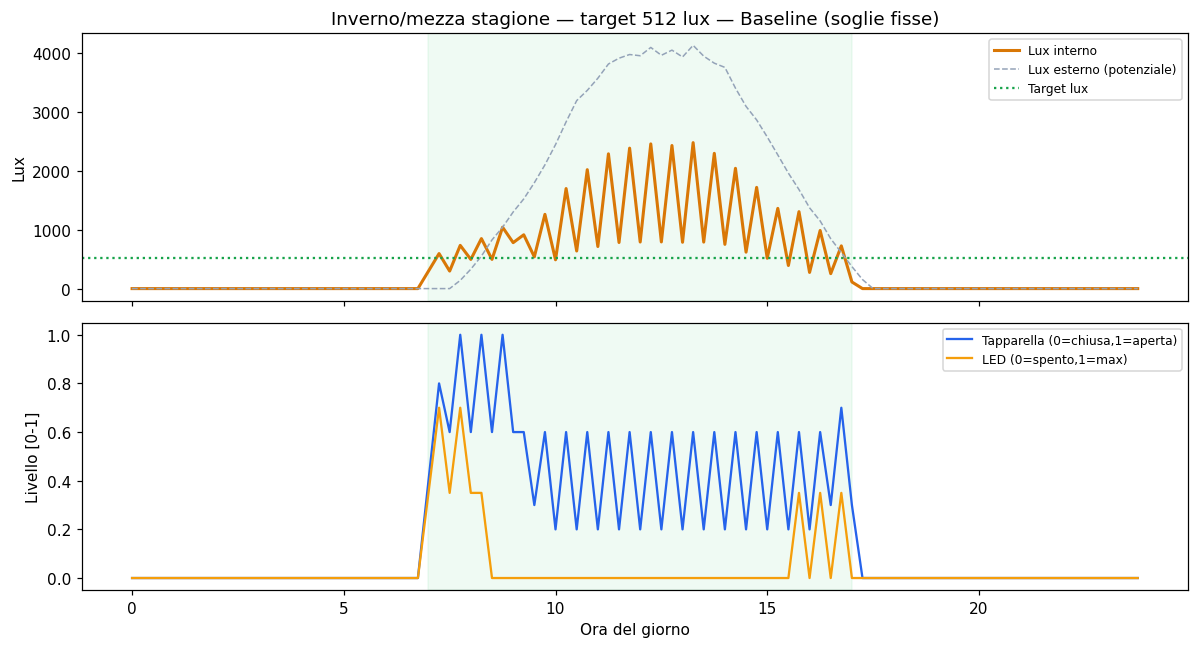

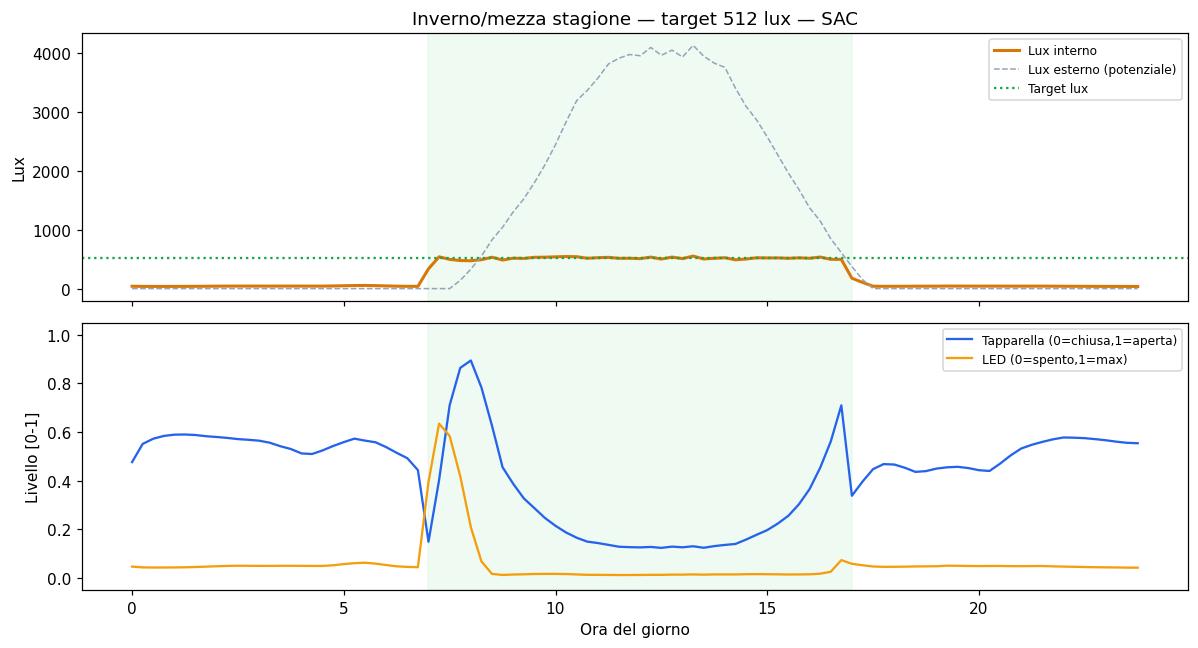

In [13]:
records_baseline_q1, target_b, season_b = run_episode(baseline, QUAL_SEED, is_baseline=True)
fig = plot_day(records_baseline_q1, target_b, season_b, title_suffix="— Baseline (soglie fisse)")
fig.savefig(os.path.join(FIG_DIR, "q1_baseline_day.png"), dpi=150)
plt.show()

records_sac_q1, target_s, season_s = run_episode(sac_for_q1, QUAL_SEED)
fig = plot_day(records_sac_q1, target_s, season_s, title_suffix="— SAC")
fig.savefig(os.path.join(FIG_DIR, "q1_sac_day.png"), dpi=150)
plt.show()

## 3. Q2 — Quale algoritmo converge meglio ed evita ottimi locali?

PPO e SAC vengono confrontati, sugli stessi `N_SEEDS` training seed
indipendenti allenati nella sezione 2, valutati da tre punti di vista:

- **trade-off** comfort luminoso vs energia, su tutti gli episodi di test;
- robustezza al seed di training (il vantaggio di un algoritmo è
  sistematico o dipende dal seed?);
- osservazione **qualitativa** del comportamento su un giorno tipo, seed
  per seed.

### Trade-off comfort luminoso vs energia

Un punto per episodio di test, per ogni training seed, quindi
`N_SEEDS x len(TEST_SEEDS)` punti per algoritmo.


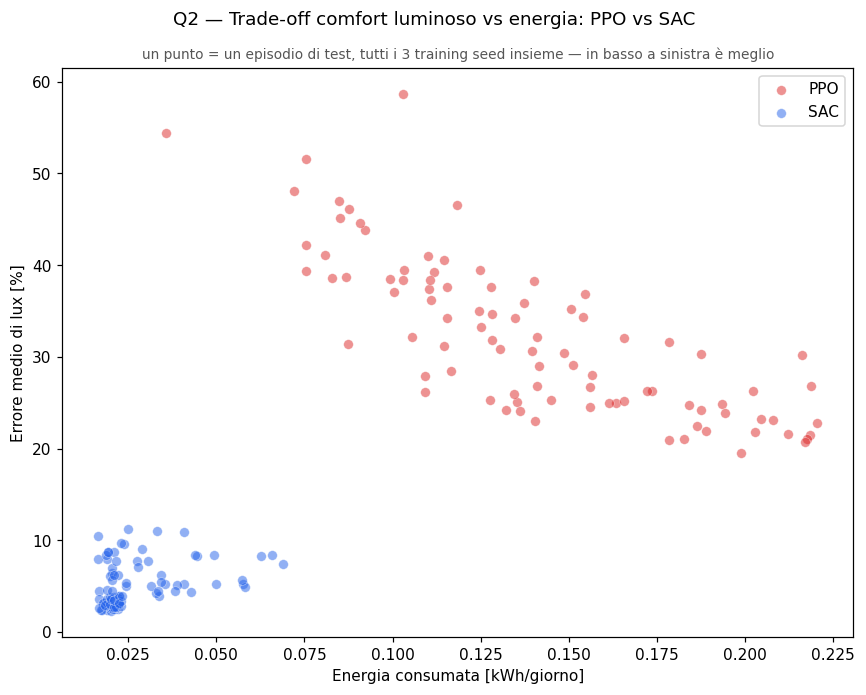

In [14]:
fig, ax = plt.subplots(figsize=(8, 6.4))
for policy, color in colors_algo.items():
    sub = df_eval[df_eval.policy == policy]
    ax.scatter(sub["energy_kwh"], sub["mean_lux_error_pct"], label=policy,
               color=color, s=40, alpha=0.5, edgecolor="white", linewidth=0.4)

ax.set_xlabel("Energia consumata [kWh/giorno]")
ax.set_ylabel("Errore medio di lux [%]")
fig.suptitle("Q2 — Trade-off comfort luminoso vs energia: PPO vs SAC", fontsize=12, y=0.98)
ax.set_title(f"un punto = un episodio di test, tutti i {len(SEEDS)} training seed insieme "
             "— in basso a sinistra è meglio", fontsize=9, color="#555555")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q2_tradeoff_scatter.png"), dpi=150)
plt.show()


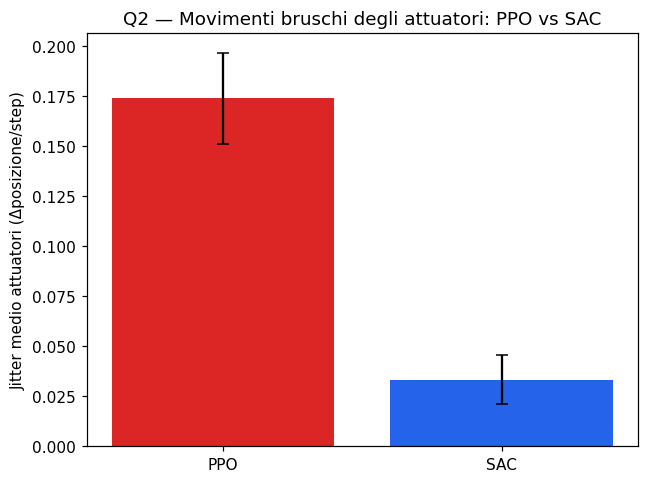

In [15]:
# Jitter degli attuatori (tutti i seed insieme)
means = df_eval.groupby("policy")["jitter_mean"].mean()
stds = df_eval.groupby("policy")["jitter_mean"].std()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(means.index, means.values, yerr=stds.values, capsize=4,
       color=[colors_algo[p] for p in means.index])
ax.set_ylabel("Jitter medio attuatori (Δposizione/step)")
ax.set_title("Q2 — Movimenti bruschi degli attuatori: PPO vs SAC")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q2_jitter.png"), dpi=150)
plt.show()


### È un ottimo locale sistematico o dipende dal seed?

Nei prossimi grafici non si raggruppa più per singolo episodio, ma per `train_seed`, per capire se le migliori prestazioni di un modello rispetto all'altro non siano solo una coincidenza legata a un singolo run di addestramento, ma derivino da una caratteristica strutturale dell'algoritmo.


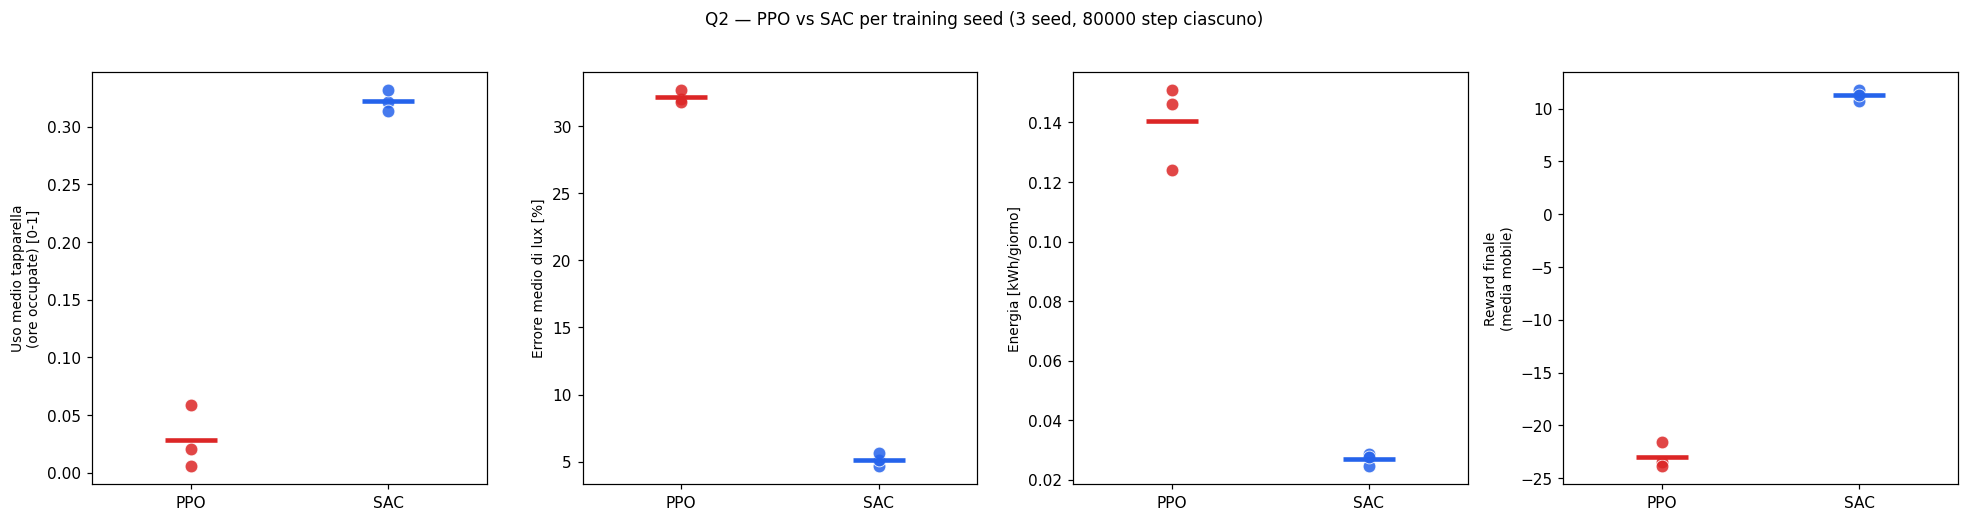

In [16]:
df_per_seed = df_eval.groupby(["policy", "train_seed"]).agg(
    mean_lux_error_pct=("mean_lux_error_pct", "mean"),
    energy_kwh=("energy_kwh", "mean"),
    mean_blind_pos_occ=("mean_blind_pos_occ", "mean"),
).reset_index()

final_rewards = []
for (algo_name, seed), log_dir in logs.items():
    _, final_y = smoothed_reward_curve(log_dir)
    final_rewards.append({
        "policy": algo_name, "train_seed": seed,
        "final_reward": float(np.mean(final_y[-5:])) if len(final_y) else float("nan"),
    })
df_per_seed = df_per_seed.merge(pd.DataFrame(final_rewards), on=["policy", "train_seed"])

metrics_per_seed = [
    ("mean_blind_pos_occ", "Uso medio tapparella\n(ore occupate) [0-1]"),
    ("mean_lux_error_pct", "Errore medio di lux [%]"),
    ("energy_kwh", "Energia [kWh/giorno]"),
    ("final_reward", "Reward finale\n(media mobile)"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for ax, (col, ylabel) in zip(axes, metrics_per_seed):
    for policy, color in colors_algo.items():
        sub = df_per_seed[df_per_seed.policy == policy]
        ax.scatter([policy] * len(sub), sub[col], color=color, s=70, alpha=0.85,
                   edgecolor="white", linewidth=0.6, zorder=3)
        ax.scatter([policy], [sub[col].mean()], color=color, marker="_", s=1200,
                   linewidth=3, zorder=4)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlim(-0.5, 1.5)

fig.suptitle(f"Q2 — PPO vs SAC per training seed ({len(SEEDS)} seed, {TIMESTEPS} step ciascuno)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q2_per_seed_summary.png"), dpi=150, bbox_inches="tight")
plt.show()


### Osservazione qualitativa: un giorno tipo, per ogni seed

Confrontiamo direttamente i due modelli su tutti i training seed, usando lo stesso episodio di test `TEST_SEEDS[0]` per ciascuno: se le differenze si ripetono su ogni seed, non sono un caso isolato ma una caratteristica del modello.


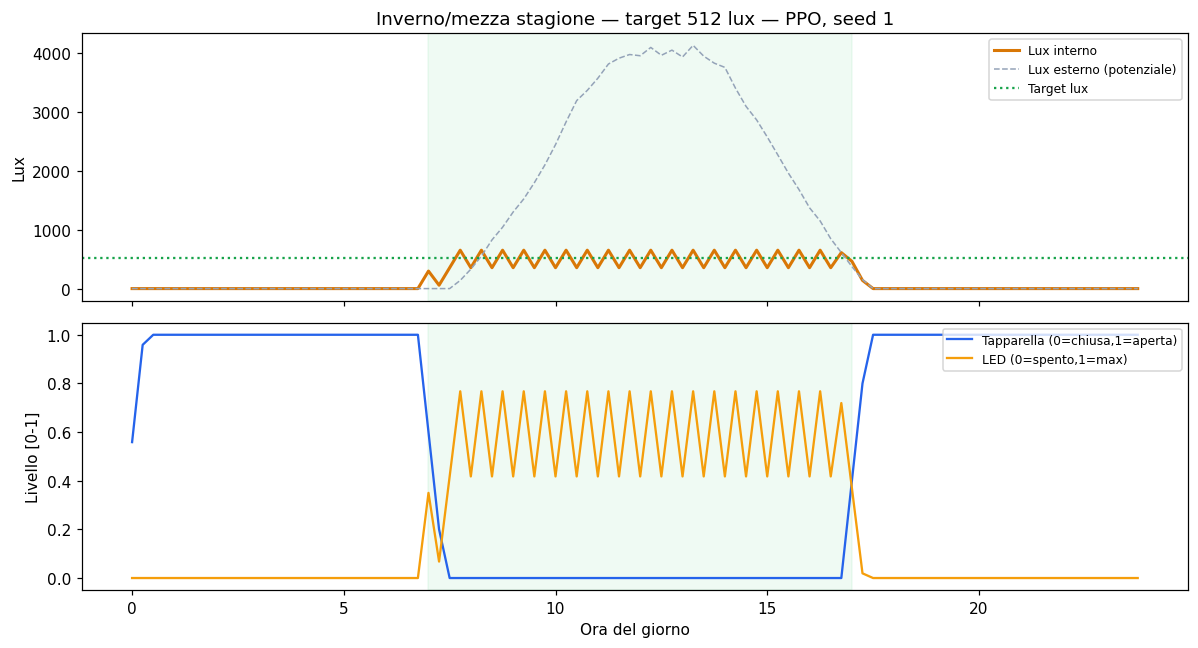

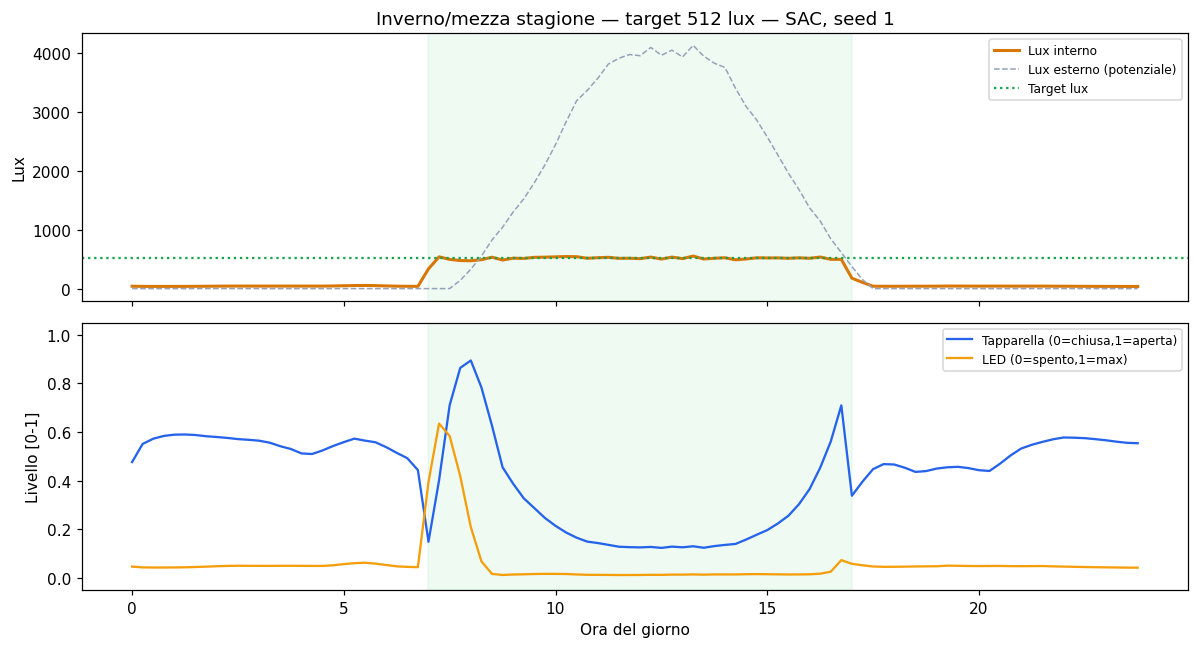

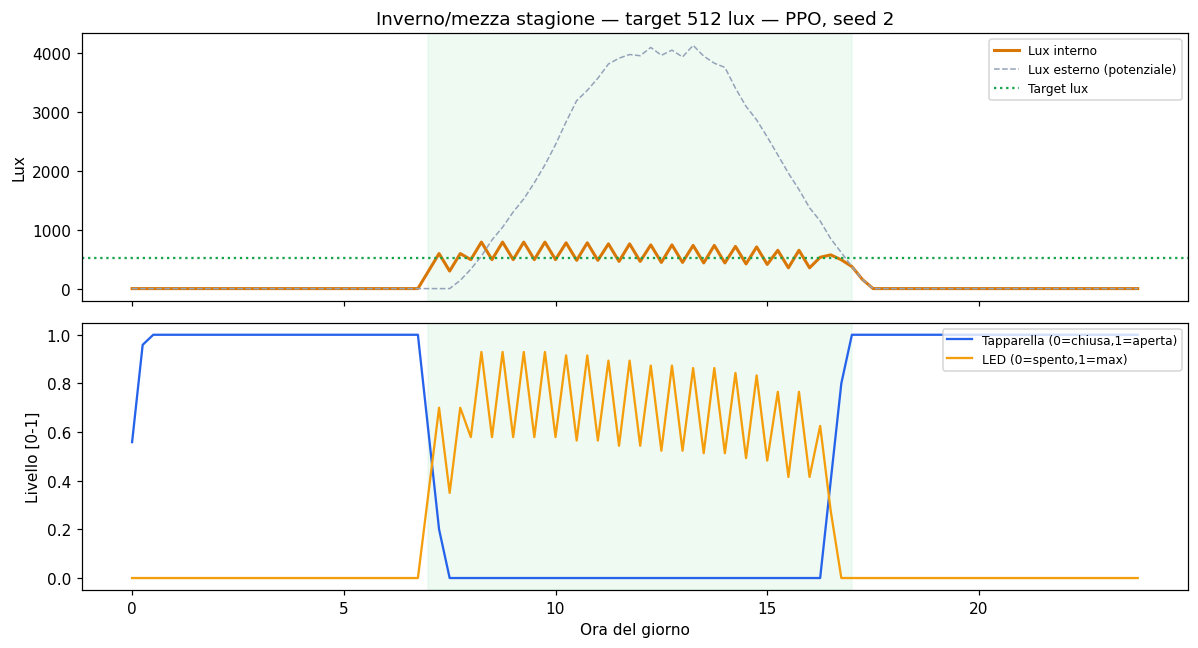

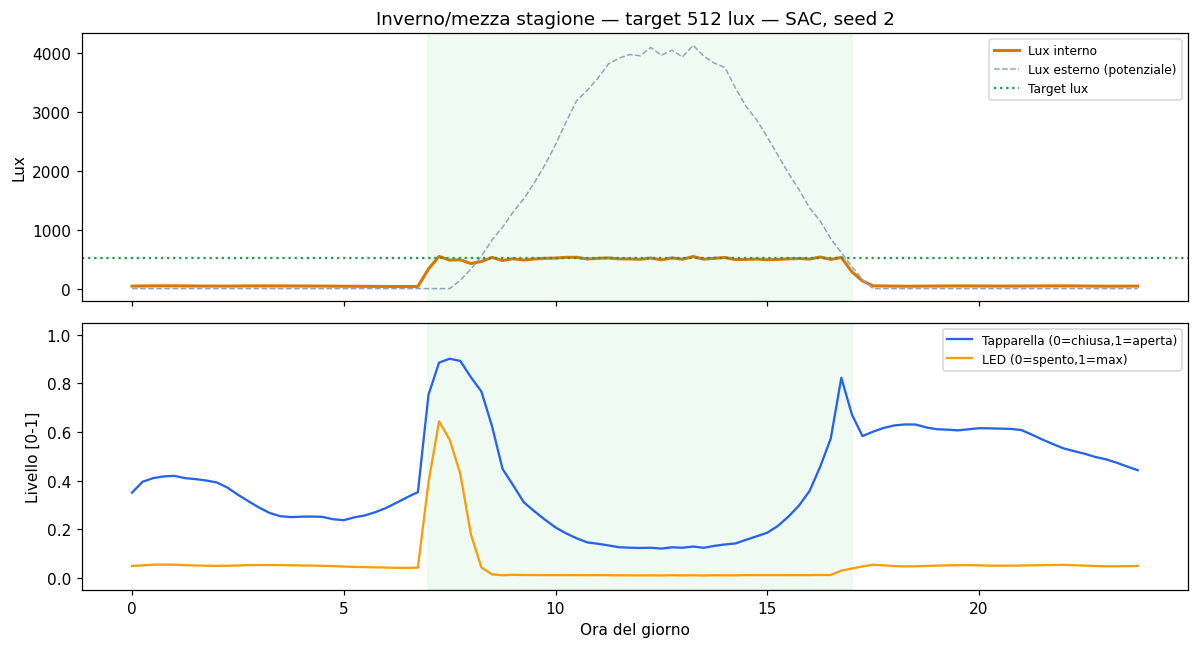

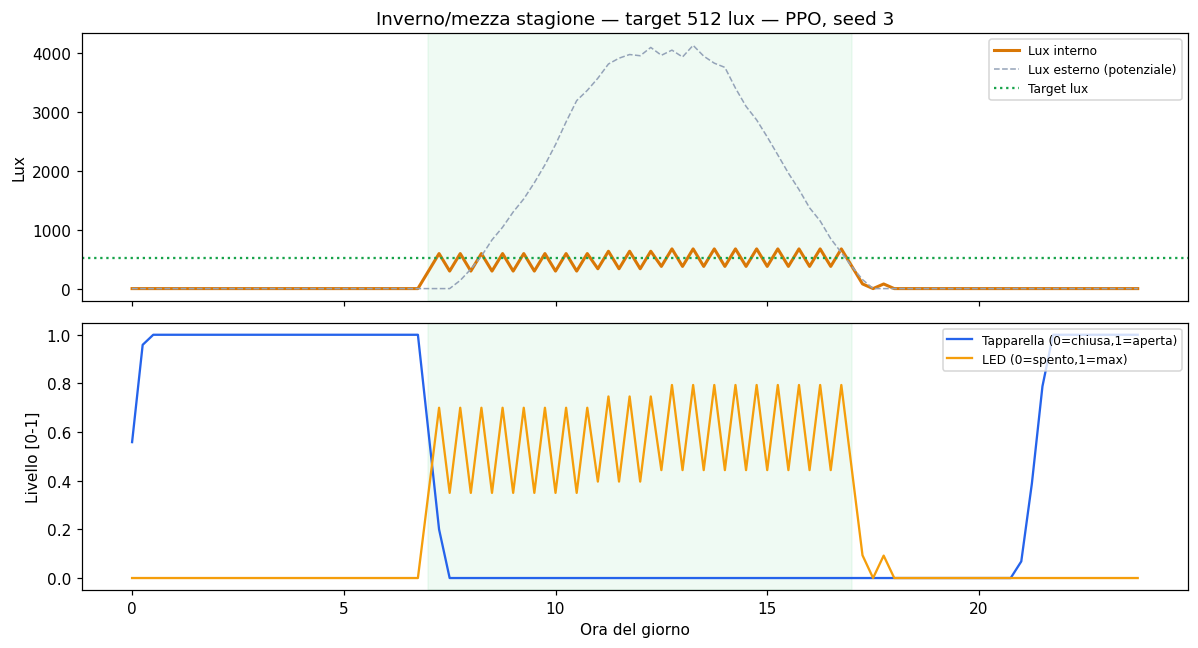

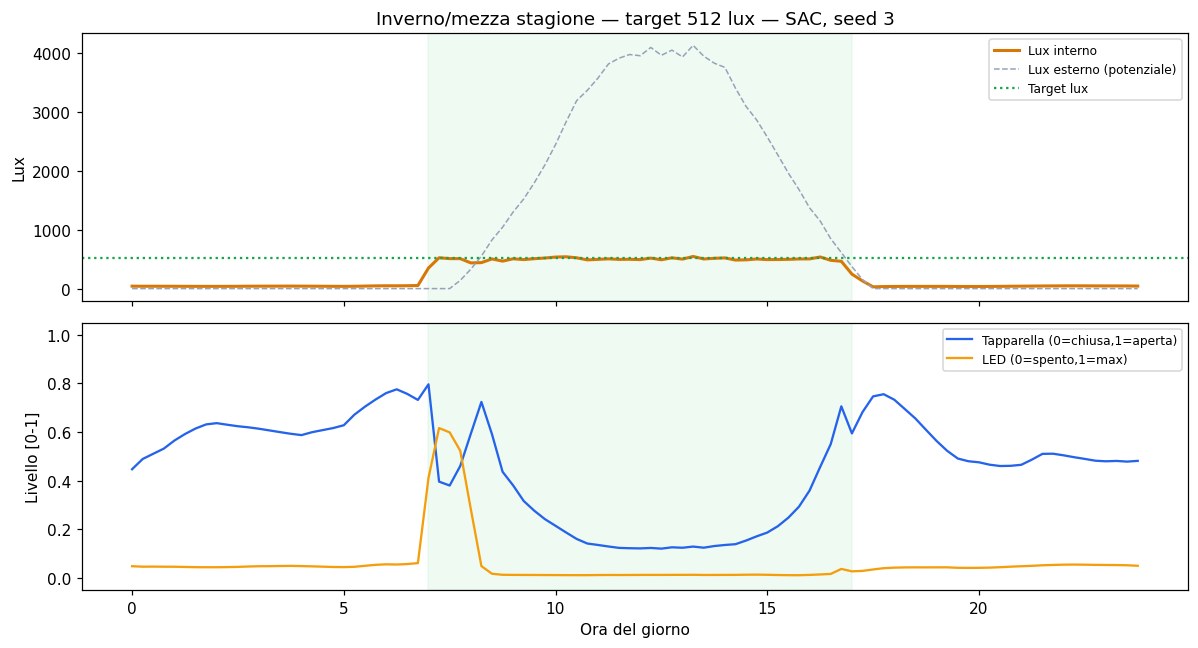

In [17]:
day_rows = []

for seed in SEEDS:
    for algo_name in ("PPO", "SAC"):
        model = models[(algo_name, seed)]
        records, target, season = run_episode(model, QUAL_SEED)
        fig = plot_day(records, target, season, title_suffix=f"— {algo_name}, seed {seed}")
        fig.savefig(os.path.join(FIG_DIR, f"q2_{algo_name.lower()}_seed{seed}_day.png"), dpi=150)
        plt.show()
        day_rows.append({"policy": algo_name, "train_seed": seed, **episode_metrics(records)})


**Aggregato per policy**

In [18]:
day_df = pd.DataFrame(day_rows)
day_df["energy_cost_eur"] = day_df["energy_kwh"].apply(energy_cost_eur)
day_summary = day_df.groupby("policy")[
    ["mean_lux_error_pct", "energy_kwh", "energy_cost_eur", "jitter_mean", "jitter_max", "mean_blind_pos_occ"]
].agg(["mean", "std"])
day_summary

mean_lux_error_pct           energy_kwh           energy_cost_eur  \
                     mean       std       mean       std            mean   
policy                                                                     
PPO             28.825632  1.970325   0.145757  0.008965        0.036439   
SAC              4.188119  0.276753   0.033394  0.000415        0.008348   

                 jitter_mean           jitter_max            \
             std        mean       std       mean       std   
policy                                                        
PPO     0.002241    0.176154  0.008347   0.750000  0.000000   
SAC     0.000104    0.047692  0.003605   0.666617  0.074856   

       mean_blind_pos_occ            
                     mean       std  
policy                               
PPO               0.03000  0.017321  
SAC               0.30687  0.023862

## 4. Q3 — La policy resta affidabile fuori distribuzione (OOD)?

`ExtremeAdaLux` è una variante dell'ambiente che genera condizioni
fuori dal range visto in training:

- target di lux in `[900, 1400]` (il training usa `[300, 750]`);
- nuvolosità quasi sempre agli estremi (foschia densa o cielo sereno
  estremo) con variazioni più rapide e ampie;
- fascia di occupazione molto più ampia (5:00–22:00 contro 7-10/17-20 del
  training).

Confrontiamo la policy SAC usata anche in Q1 (`sac_for_q1`, seed
`SEEDS[0]`) su episodi "normali" vs "estremi" (stessi seed per le due
condizioni), guardando errore di lux, energia e il **jitter degli
attuatori** (movimento medio e massimo per step) come proxy di
movimenti bruschi.

In [19]:
import numpy as np

class ExtremeAdaLux(AdaLux):

    EXTREME_LUX_TARGET_RANGE = (900.0, 1400.0)

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        self.lux_target = float(self._rng.uniform(*self.EXTREME_LUX_TARGET_RANGE))
        if self._rng.random() < 0.5:
            self.cloud_factor = float(self._rng.uniform(0.05, 0.15))
        else:
            self.cloud_factor = float(self._rng.uniform(0.95, 1.0))
        self.occupancy_start = 5
        self.occupancy_end = 22
        obs = self._build_obs()
        return obs, info

    def _update_cloud_factor(self):
        step = self._rng.normal(0, 0.12)
        self.cloud_factor = float(np.clip(self.cloud_factor + step, 0.02, 1.0))


print("ExtremeAdaLux definito.")


ExtremeAdaLux definito.


In [20]:
df_normal = evaluate_over_seeds(sac_for_q1, TEST_SEEDS, env_cls=AdaLux, label="Normale")
df_extreme = evaluate_over_seeds(sac_for_q1, TEST_SEEDS, env_cls=ExtremeAdaLux, label="Estremo (OOD)")

df_q3 = pd.concat([df_normal, df_extreme], ignore_index=True)
df_q3["energy_cost_eur"] = df_q3["energy_kwh"].apply(energy_cost_eur)
summary_q3 = df_q3.groupby("policy")[["mean_lux_error_pct", "energy_kwh", "energy_cost_eur", "jitter_mean", "jitter_max"]].agg(["mean", "std"])
summary_q3


Valutazione Normale:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione Estremo (OOD):   0%|          | 0/30 [00:00<?, ?it/s]

mean_lux_error_pct           energy_kwh            \
                            mean       std       mean       std   
policy                                                            
Estremo (OOD)          36.637672  6.580031   0.166073  0.051599   
Normale                 4.710461  2.087533   0.028737  0.013311   

              energy_cost_eur           jitter_mean           jitter_max  \
                         mean       std        mean       std       mean   
policy                                                                     
Estremo (OOD)        0.041518  0.012900    0.104144  0.026973   0.666478   
Normale              0.007184  0.003328    0.034355  0.015012   0.390289   

                         
                    std  
policy                   
Estremo (OOD)  0.039900  
Normale        0.166546

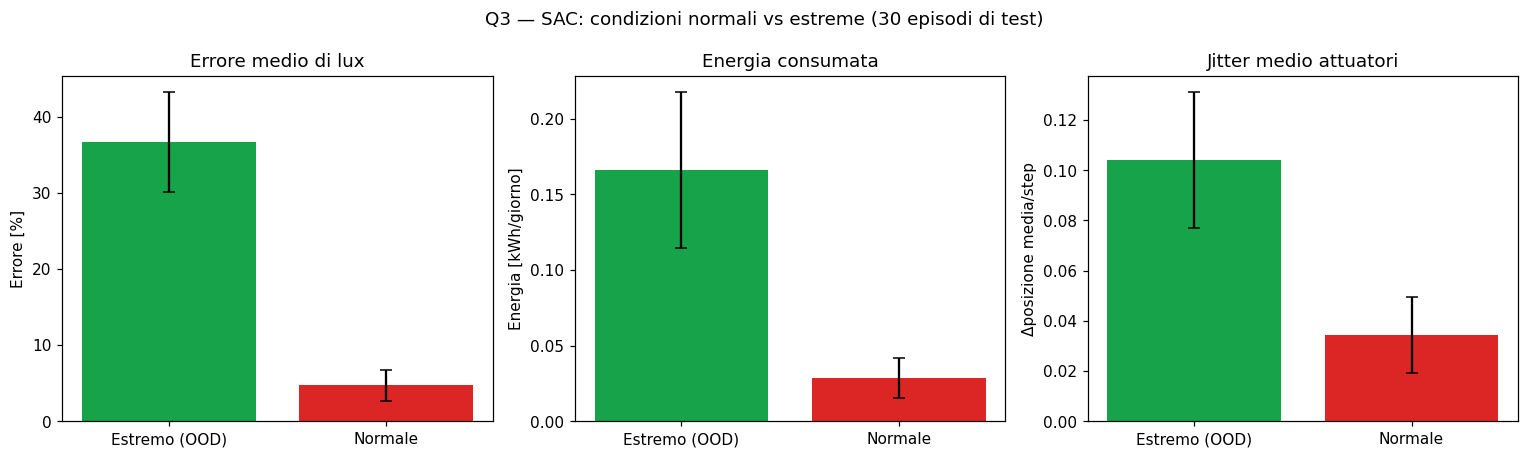

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

panels = [
    ("mean_lux_error_pct", "Errore medio di lux", "Errore [%]"),
    ("energy_kwh", "Energia consumata", "Energia [kWh/giorno]"),
    ("jitter_mean", "Jitter medio attuatori", "Δposizione media/step"),
]
colors = ["#16a34a", "#dc2626"]
for ax, (col, title, ylabel) in zip(axes, panels):
    means = df_q3.groupby("policy")[col].mean()
    stds = df_q3.groupby("policy")[col].std()
    ax.bar(means.index, means.values, yerr=stds.values, capsize=4, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f"Q3 — SAC: condizioni normali vs estreme ({len(TEST_SEEDS)} episodi di test)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q3_normal_vs_extreme.png"), dpi=150)
plt.show()


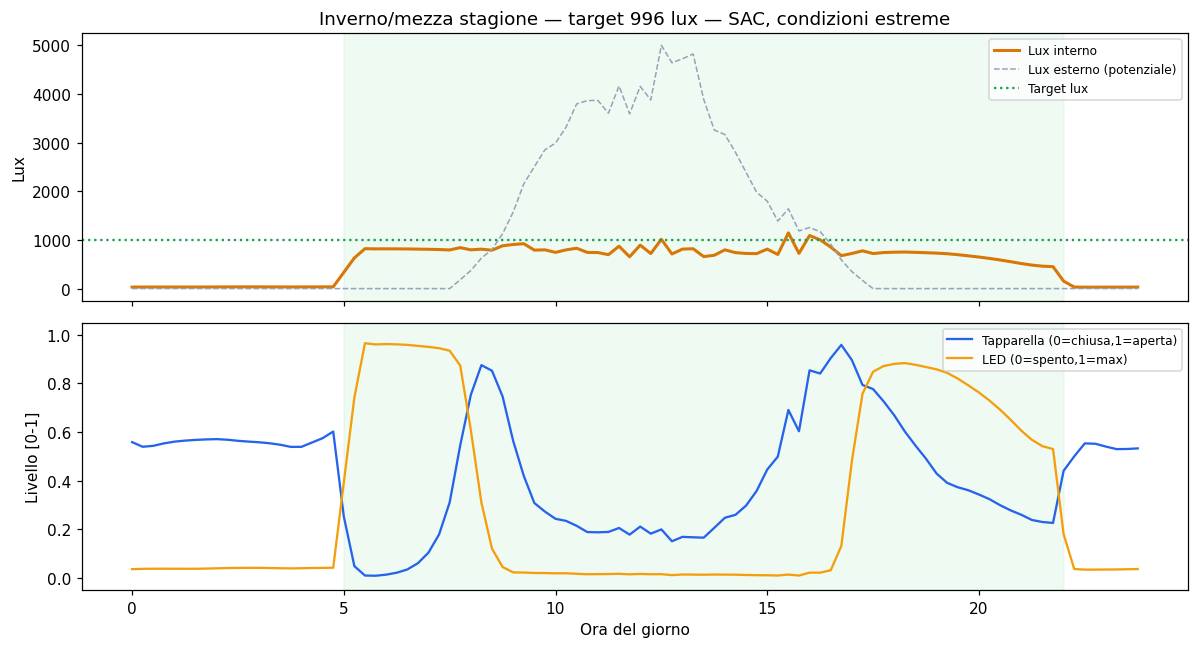

,mean_lux_error_pct,energy_kwh,jitter_mean,jitter_max,mean_blind_pos_occ,energy_cost_eur
0,25.091848,0.170496,0.086375,0.698842,0.377892,0.042624


In [22]:
# Ispezione qualitativa di un singolo episodio estremo
records_extreme, target_extreme, season_extreme = run_episode(sac_for_q1, QUAL_SEED, env_cls=ExtremeAdaLux)
fig_extreme = plot_day(records_extreme, target_extreme, season_extreme, title_suffix="— SAC, condizioni estreme")
fig_extreme.savefig(os.path.join(FIG_DIR, "q3_extreme_day.png"), dpi=150)
plt.show()

metrics_extreme = episode_metrics(records_extreme)
metrics_extreme["energy_cost_eur"] = energy_cost_eur(metrics_extreme["energy_kwh"])
pd.DataFrame([metrics_extreme])
